<a href="https://colab.research.google.com/github/DAKSHM77/Current-Quench-Classificaiton-ML-Project/blob/main/1_ADITYA_U_PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
folder_path = "/content/drive/MyDrive/ADITYA_U_PROJECT/Data"

In [ ]:
files = glob.glob(
    os.path.join(folder_path, "*.txt")
)

print("Total Files =", len(files))

Total Files = 1521


In [ ]:
sample_file = files[0]

df = pd.read_csv(
    sample_file,
    sep=r"\s+",
    header=None,
    names=["Time", "Current"]
)

df.head()

,Time,Current
0,-51.0,-0.002582
1,-50.8,-0.005163
2,-50.6,-0.007745
3,-50.4,-0.005979
4,-50.2,-0.004212


In [ ]:
peak_idx = df["Current"].idxmax()

print("Peak Index =", peak_idx)

Peak Index = 549


In [ ]:
peak_time = df.loc[peak_idx, "Time"]

print("Peak Time =", peak_time)

Peak Time = 58.8


In [ ]:
start_time = peak_time - 15
end_time = peak_time + 5

window_df = df[
    (df["Time"] >= start_time)
    &
    (df["Time"] <= end_time)
]

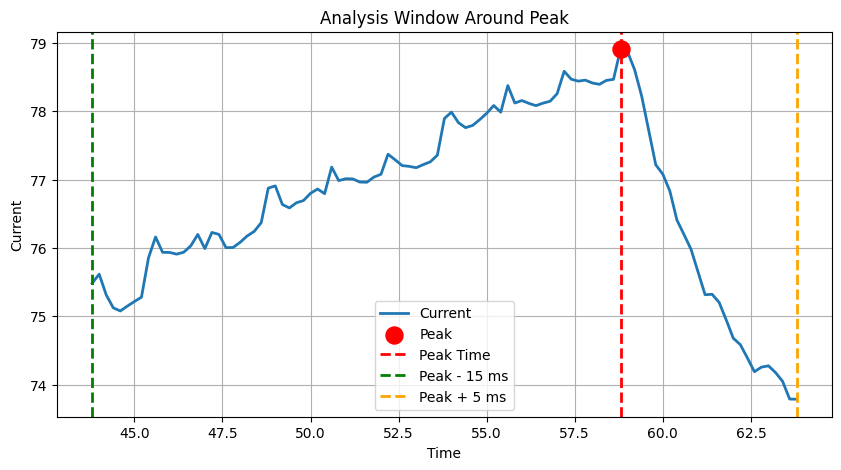

In [ ]:
plt.figure(figsize=(10,5))

# Current signal
plt.plot(
    window_df["Time"],
    window_df["Current"],
    linewidth=2,
    label="Current"
)

# Peak point
plt.scatter(
    peak_time,
    df.loc[peak_idx, "Current"],
    color="red",
    s=150,
    zorder=5,
    label="Peak"
)

# Peak line
plt.axvline(
    x=peak_time,
    color="red",
    linestyle="--",
    linewidth=2,
    label="Peak Time"
)

# 15 ms Before Peak
plt.axvline(
    x=start_time,
    color="green",
    linestyle="--",
    linewidth=2,
    label="Peak - 15 ms"
)

# 5 ms After Peak
plt.axvline(
    x=end_time,
    color="orange",
    linestyle="--",
    linewidth=2,
    label="Peak + 5 ms"
)

plt.title("Analysis Window Around Peak")
plt.xlabel("Time")
plt.ylabel("Current")
plt.grid(True)
plt.legend()

plt.show()

In [ ]:
def extract_features(window_df):

    features = {}

    features["Mean_Current"] = window_df["Current"].mean()

    features["Std_Current"] = window_df["Current"].std()

    features["Max_Current"] = window_df["Current"].max()

    features["Min_Current"] = window_df["Current"].min()

    features["Range_Current"] = (
        features["Max_Current"]
        -
        features["Min_Current"]
    )

    return features

In [ ]:
features = extract_features(window_df)

print(features)

{'Mean_Current': np.float64(76.68701555536605), 'Std_Current': 1.3146228091893606, 'Max_Current': 78.9065071709349, 'Min_Current': 73.7851485049736, 'Range_Current': 5.121358665961296}


In [ ]:
window_df["Slope"] = np.gradient(
    window_df["Current"],
    window_df["Time"]
)

window_df.head()

/tmp/ipykernel_3130/3161556189.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  window_df["Slope"] = np.gradient(


,Time,Current,Slope
474,43.8,75.482530,0.661044
475,44.0,75.614739,-0.425976
476,44.2,75.312140,-1.230371
477,44.4,75.122591,-0.589029
478,44.6,75.076528,0.063183


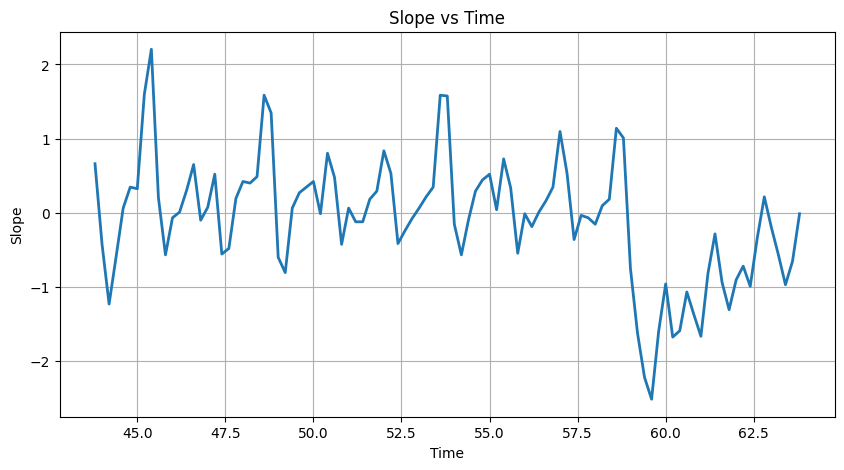

In [ ]:
# Create slope column if not already present

window_df = window_df.copy()

window_df["Slope"] = np.gradient(
    window_df["Current"].values,
    window_df["Time"].values
)

# Plot Slope vs Time

plt.figure(figsize=(10,5))

plt.plot(
    window_df["Time"],
    window_df["Slope"],
    linewidth=2
)

plt.title("Slope vs Time")
plt.xlabel("Time")
plt.ylabel("Slope")
plt.grid(True)

plt.show()

In [ ]:
print("Mean Slope =", window_df["Slope"].mean())

print("Max Slope =", window_df["Slope"].max())

print("Min Slope =", window_df["Slope"].min())

print("Slope Std =", window_df["Slope"].std())

Mean Slope = -0.08082020312058606
Max Slope = 2.2046123571999203
Min Slope = -2.5130542709653128
Slope Std = 0.8226642983936743


In [ ]:
positive_count = (
    window_df["Slope"] > 0
).sum()

negative_count = (
    window_df["Slope"] < 0
).sum()

print("Positive Slopes =", positive_count)

print("Negative Slopes =", negative_count)

Positive Slopes = 50
Negative Slopes = 51


In [ ]:
def extract_features(window_df):

    features = {}

    # Current Features

    features["Mean_Current"] = (
        window_df["Current"].mean()
    )

    features["Std_Current"] = (
        window_df["Current"].std()
    )

    features["Max_Current"] = (
        window_df["Current"].max()
    )

    features["Min_Current"] = (
        window_df["Current"].min()
    )

    features["Range_Current"] = (
        features["Max_Current"]
        -
        features["Min_Current"]
    )

    # Slope Features

    slope = np.gradient(
        window_df["Current"],
        window_df["Time"]
    )

    features["Mean_Slope"] = slope.mean()

    features["Std_Slope"] = slope.std()

    features["Max_Slope"] = slope.max()

    features["Min_Slope"] = slope.min()

    features["Positive_Slope_Count"] = (
        slope > 0
    ).sum()

    features["Negative_Slope_Count"] = (
        slope < 0
    ).sum()

    return features

In [ ]:
features = extract_features(
    window_df
)

features

{'Mean_Current': np.float64(76.68701555536605),
 'Std_Current': 1.3146228091893606,
 'Max_Current': 78.9065071709349,
 'Min_Current': 73.7851485049736,
 'Range_Current': 5.121358665961296,
 'Mean_Slope': np.float64(-0.08082020312058606),
 'Std_Slope': np.float64(0.8185815719597137),
 'Max_Slope': np.float64(2.2046123571999203),
 'Min_Slope': np.float64(-2.5130542709653128),
 'Positive_Slope_Count': np.int64(50),
 'Negative_Slope_Count': np.int64(51)}

In [ ]:
feature_df = pd.DataFrame(
    [features]
)

feature_df

,Mean_Current,Std_Current,Max_Current,Min_Current,Range_Current,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Positive_Slope_Count,Negative_Slope_Count
0,76.687016,1.314623,78.906507,73.785149,5.121359,-0.08082,0.818582,2.204612,-2.513054,50,51


In [ ]:
def extract_features(window_df):

    features = {}

    # Current Features

    features["Mean_Current"] = window_df["Current"].mean()

    features["Std_Current"] = window_df["Current"].std()

    features["Max_Current"] = window_df["Current"].max()

    features["Min_Current"] = window_df["Current"].min()

    features["Range_Current"] = (
        features["Max_Current"]
        - features["Min_Current"]
    )

    # Slope Calculation

    slope = np.gradient(
        window_df["Current"].values,
        window_df["Time"].values
    )

    # Slope Features

    features["Mean_Slope"] = slope.mean()

    features["Std_Slope"] = slope.std()

    features["Max_Slope"] = slope.max()

    features["Min_Slope"] = slope.min()

    features["Positive_Slope_Count"] = (
        slope > 0
    ).sum()

    features["Negative_Slope_Count"] = (
        slope < 0
    ).sum()

    return features

In [ ]:
all_features = []

In [ ]:
test_file = files[0]

print("Testing:", test_file)

df = pd.read_csv(
    test_file,
    sep=r"\s+",
    header=None,
    names=["Time", "Current"]
)

print("Data Loaded")
print(df.head())

peak_idx = df["Current"].idxmax()

print("Peak Index =", peak_idx)

peak_time = df.loc[peak_idx, "Time"]

print("Peak Time =", peak_time)

start_time = peak_time - 15
end_time = peak_time + 5

window_df = df[
    (df["Time"] >= start_time)
    &
    (df["Time"] <= end_time)
].copy()

print("Window Shape =", window_df.shape)

print(window_df.head())

Testing: /content/drive/MyDrive/ADITYA_U_PROJECT/Data/SG_ADIip_data23757.txt
Data Loaded
   Time   Current
0 -51.0 -0.002582
1 -50.8 -0.005163
2 -50.6 -0.007745
3 -50.4 -0.005979
4 -50.2 -0.004212
Peak Index = 549
Peak Time = 58.8
Window Shape = (101, 2)
     Time    Current
474  43.8  75.482530
475  44.0  75.614739
476  44.2  75.312140
477  44.4  75.122591
478  44.6  75.076528


In [ ]:
features = extract_features(window_df)

print(features)

{'Mean_Current': np.float64(76.68701555536605), 'Std_Current': 1.3146228091893606, 'Max_Current': 78.9065071709349, 'Min_Current': 73.7851485049736, 'Range_Current': 5.121358665961296, 'Mean_Slope': np.float64(-0.08082020312058606), 'Std_Slope': np.float64(0.8185815719597137), 'Max_Slope': np.float64(2.2046123571999203), 'Min_Slope': np.float64(-2.5130542709653128), 'Positive_Slope_Count': np.int64(50), 'Negative_Slope_Count': np.int64(51)}


In [ ]:
all_features = []

In [ ]:
all_features = []

for file in files:

    try:

        df = pd.read_csv(
            file,
            sep=r"\s+",
            header=None,
            names=["Time", "Current"]
        )

        peak_idx = df["Current"].idxmax()

        peak_time = df.loc[peak_idx, "Time"]

        start_time = peak_time - 15
        end_time = peak_time + 5

        window_df = df[
            (df["Time"] >= start_time)
            &
            (df["Time"] <= end_time)
        ].copy()

        if len(window_df) == 0:
            continue

        features = extract_features(window_df)

        features["File"] = os.path.basename(file)

        all_features.append(features)

    except Exception as e:

        print(
            "Error in:",
            os.path.basename(file)
        )

        print(e)

In [ ]:
print(len(all_features))

1521


In [ ]:
feature_df = pd.DataFrame(all_features)

print(feature_df.shape)

feature_df.head()

(1521, 12)


,Mean_Current,Std_Current,Max_Current,Min_Current,Range_Current,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Positive_Slope_Count,Negative_Slope_Count,File
0,76.687016,1.314623,78.906507,73.785149,5.121359,-0.080820,0.818582,2.204612,-2.513054,50,51,SG_ADIip_data23757.txt
1,11.557047,11.513571,31.201159,-0.015694,31.216852,0.843003,3.404792,7.654744,-8.161397,58,43,SG_ADIip_data23314.txt
2,20.961603,12.826700,34.195610,-0.042173,34.237783,0.205015,5.585646,8.362665,-32.694079,57,43,SG_ADIip_data23961.txt
3,13.737040,12.846530,31.400236,-0.155902,31.556138,0.778204,3.496795,8.757899,-11.493283,63,38,SG_ADIip_data23960.txt
4,59.664183,6.720402,70.907331,45.438250,25.469081,0.021031,3.766246,11.058050,-19.215456,69,32,SG_ADIip_data23588.txt


In [ ]:
feature_df[[
    "Mean_Slope",
    "Max_Slope",
    "Min_Slope",
    "Std_Slope"
]].describe()

,Mean_Slope,Max_Slope,Min_Slope,Std_Slope
count,1521.000000,1521.000000,1521.000000,1521.000000
mean,-0.002842,3.596449,-10.626861,2.488205
std,0.863599,3.310914,15.669674,2.872780
min,-4.217008,0.020042,-44.644844,0.008519
25%,-0.071482,1.781099,-12.302433,0.653335
50%,0.153439,2.273570,-1.897529,0.888201
75%,0.429962,3.604235,-1.256867,3.487849
max,4.839344,24.797133,4.596481,11.613341


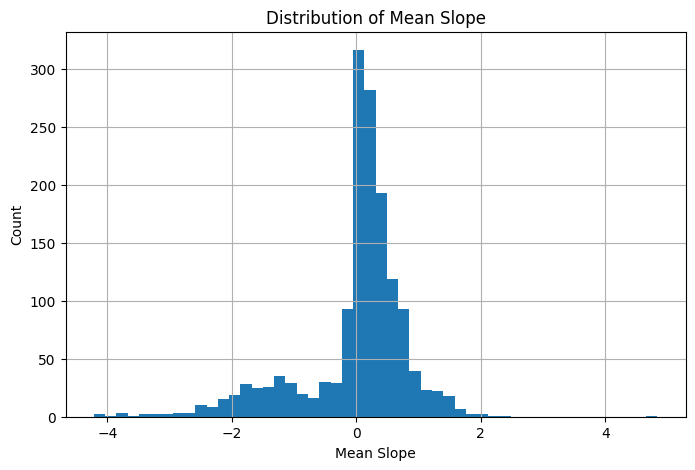

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_df["Mean_Slope"],
    bins=50
)

plt.title("Distribution of Mean Slope")
plt.xlabel("Mean Slope")
plt.ylabel("Count")

plt.grid(True)

plt.show()

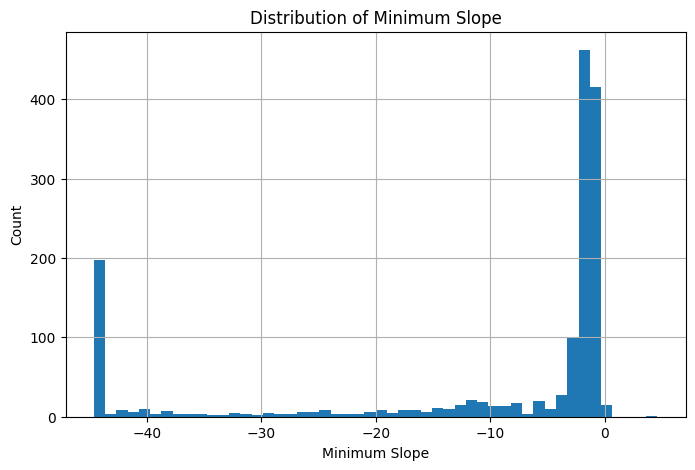

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_df["Min_Slope"],
    bins=50
)

plt.title("Distribution of Minimum Slope")
plt.xlabel("Minimum Slope")
plt.ylabel("Count")

plt.grid(True)

plt.show()

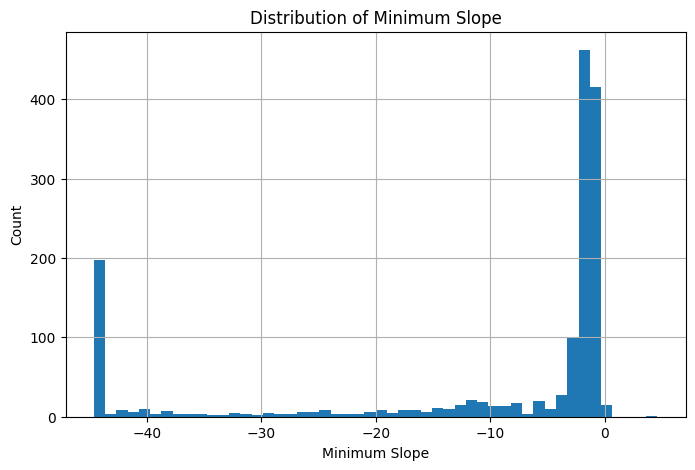

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_df["Min_Slope"],
    bins=50
)

plt.title("Distribution of Minimum Slope")
plt.xlabel("Minimum Slope")
plt.ylabel("Count")

plt.grid(True)

plt.show()

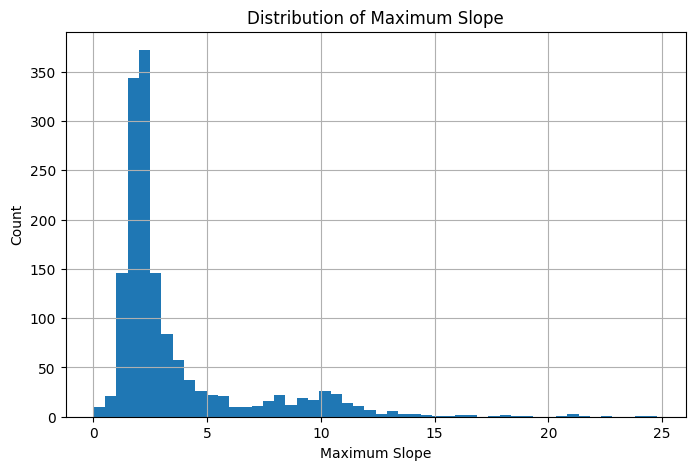

In [ ]:
plt.figure(figsize=(8,5))

plt.hist(
    feature_df["Max_Slope"],
    bins=50
)

plt.title("Distribution of Maximum Slope")
plt.xlabel("Maximum Slope")
plt.ylabel("Count")

plt.grid(True)

plt.show()

In [ ]:
feature_df["Slope_Range"] = (
    feature_df["Max_Slope"]
    - feature_df["Min_Slope"]
)

feature_df.head()

,Mean_Current,Std_Current,Max_Current,Min_Current,Range_Current,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Positive_Slope_Count,Negative_Slope_Count,File,Slope_Range
0,76.687016,1.314623,78.906507,73.785149,5.121359,-0.080820,0.818582,2.204612,-2.513054,50,51,SG_ADIip_data23757.txt,4.717667
1,11.557047,11.513571,31.201159,-0.015694,31.216852,0.843003,3.404792,7.654744,-8.161397,58,43,SG_ADIip_data23314.txt,15.816140
2,20.961603,12.826700,34.195610,-0.042173,34.237783,0.205015,5.585646,8.362665,-32.694079,57,43,SG_ADIip_data23961.txt,41.056744
3,13.737040,12.846530,31.400236,-0.155902,31.556138,0.778204,3.496795,8.757899,-11.493283,63,38,SG_ADIip_data23960.txt,20.251182
4,59.664183,6.720402,70.907331,45.438250,25.469081,0.021031,3.766246,11.058050,-19.215456,69,32,SG_ADIip_data23588.txt,30.273506


In [ ]:
feature_df[[
    "Mean_Slope",
    "Std_Slope",
    "Max_Slope",
    "Min_Slope",
    "Slope_Range"
]].describe()

,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Slope_Range
count,1521.000000,1521.000000,1521.000000,1521.000000,1521.000000
mean,-0.002842,2.488205,3.596449,-10.626861,14.223310
std,0.863599,2.872780,3.310914,15.669674,17.298181
min,-4.217008,0.008519,0.020042,-44.644844,0.043481
25%,-0.071482,0.653335,1.781099,-12.302433,3.250190
50%,0.153439,0.888201,2.273570,-1.897529,4.021974
75%,0.429962,3.487849,3.604235,-1.256867,19.696802
max,4.839344,11.613341,24.797133,4.596481,68.536609


In [ ]:
feature_df.sort_values(
    by="Slope_Range",
    ascending=False
).head(20)

,Mean_Current,Std_Current,Max_Current,Min_Current,Range_Current,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Positive_Slope_Count,Negative_Slope_Count,File,Slope_Range
680,40.868334,4.857873,56.852537,32.018954,24.833582,0.231515,5.875535,23.953334,-44.583274,63,37,SG_ADIip_data23274.txt,68.536609
936,63.611412,17.415197,82.106830,1.397585,80.709245,-3.158700,9.197193,19.125861,-44.432196,61,39,SG_ADIip_data24022.txt,63.558057
35,45.620140,15.312080,59.363281,16.085467,43.277814,-1.838867,8.506288,16.864011,-44.596098,46,55,SG_ADIip_data23437.txt,61.460109
824,38.471920,10.640329,47.441644,7.848828,39.592817,-1.323633,7.934422,15.773254,-44.599835,57,44,SG_ADIip_data23347.txt,60.373089
695,23.077449,5.414110,38.734394,16.251526,22.482868,-0.555270,6.369187,22.339109,-37.881796,51,49,SG_ADIip_data23315.txt,60.220906
254,47.775715,16.969449,65.778109,15.329801,50.448308,-1.346078,9.241088,14.799182,-44.432535,64,37,SG_ADIip_data23997.txt,59.231718
536,37.239825,16.077225,49.853929,3.598410,46.255519,-2.106122,8.807252,13.466309,-44.460985,38,62,SG_ADIip_data24550.txt,57.927294
730,66.059775,19.944247,79.907568,26.751256,53.156312,-2.510462,9.262264,13.179692,-44.584548,32,68,SG_ADIip_data23301.txt,57.764241
873,76.964029,12.807258,86.825923,29.183361,57.642562,-2.880754,7.594071,13.225976,-44.342601,23,78,SG_ADIip_data23224.txt,57.568577
968,79.286606,12.095627,88.046782,23.665970,64.380812,-3.044198,9.348007,13.084918,-44.157553,48,53,SG_ADIip_data23626.txt,57.242471


In [ ]:
feature_df.sort_values(
    by="Std_Slope",
    ascending=True
).head(20)

,Mean_Current,Std_Current,Max_Current,Min_Current,Range_Current,Mean_Slope,Std_Slope,Max_Slope,Min_Slope,Positive_Slope_Count,Negative_Slope_Count,File,Slope_Range
959,224.701458,0.015917,224.728740,224.678126,0.050614,0.000454,0.008519,0.020042,-0.023439,25,76,SG_ADIip_data24486.txt,0.043481
652,80.236156,0.008094,80.250471,80.216910,0.033562,0.001029,0.009504,0.025137,-0.029214,73,28,SG_ADIip_data24480.txt,0.054351
958,85.567068,0.012200,85.579774,85.531996,0.047778,0.001783,0.009674,0.034394,-0.019957,79,22,SG_ADIip_data24488.txt,0.054351
637,40.816309,0.029077,40.859993,40.770178,0.089815,0.003041,0.010192,0.033715,-0.009766,72,29,SG_ADIip_data24484.txt,0.043481
980,100.717298,0.021822,100.748577,100.675610,0.072966,-0.000133,0.011299,0.026666,-0.049425,49,52,SG_ADIip_data24483.txt,0.076091
909,259.321974,0.009530,259.340543,259.301478,0.039065,-0.000441,0.011689,0.030233,-0.034988,42,59,SG_ADIip_data24490.txt,0.065221
818,113.518122,0.029835,113.556389,113.445377,0.111012,0.003051,0.012037,0.025222,-0.029129,67,34,SG_ADIip_data24479.txt,0.054351
903,114.299119,0.019774,114.335834,114.269916,0.065918,-0.000798,0.013143,0.020297,-0.034054,41,60,SG_ADIip_data24478.txt,0.054351
858,81.094255,0.026259,81.133132,81.046680,0.086452,0.002528,0.013372,0.052143,-0.034819,53,48,SG_ADIip_data24481.txt,0.086962
798,236.961305,0.025736,237.008176,236.887194,0.120982,-0.003248,0.015246,0.026241,-0.038980,57,44,SG_ADIip_data24487.txt,0.065221


In [ ]:
import random

sample_files = random.sample(files, 20)

print("Selected", len(sample_files), "files")

Selected 20 files


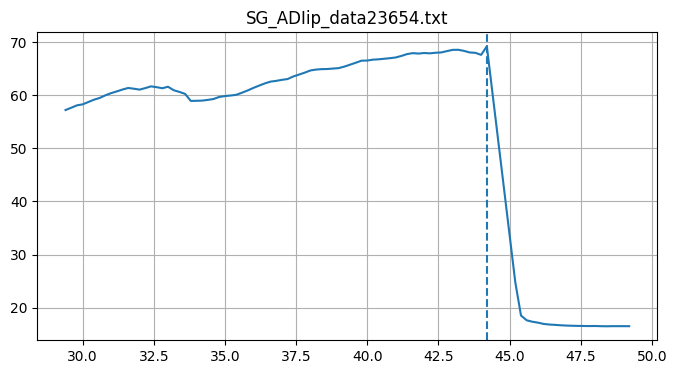

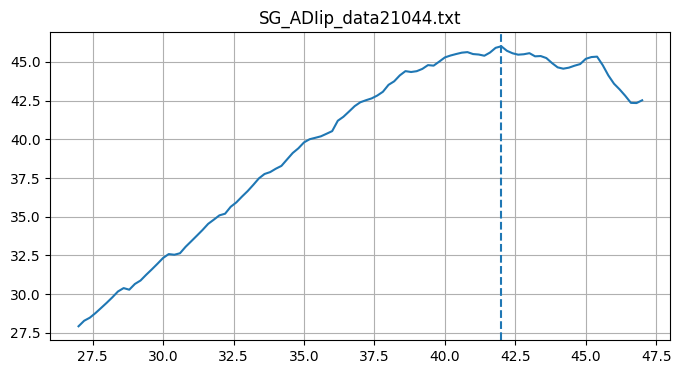

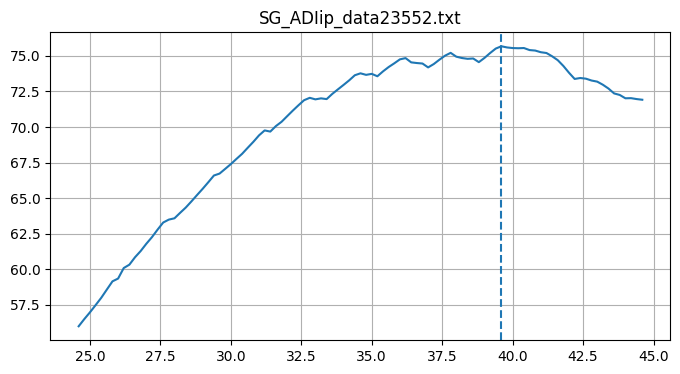

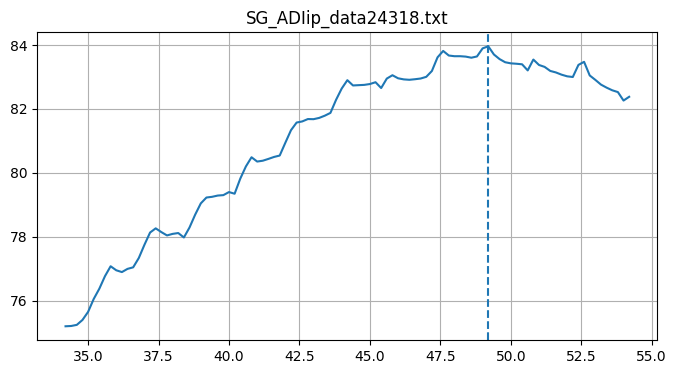

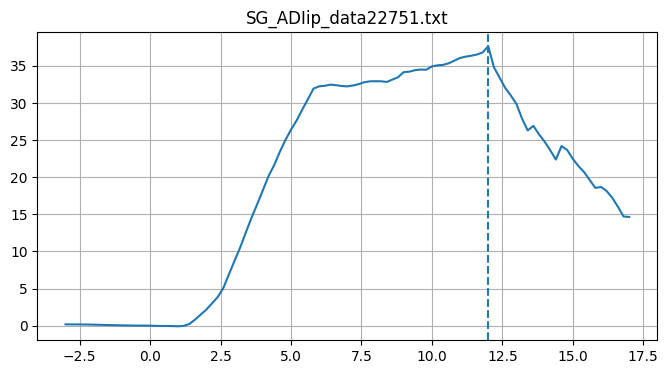

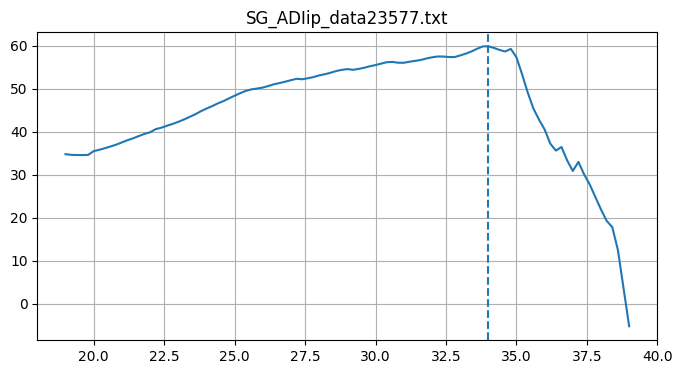

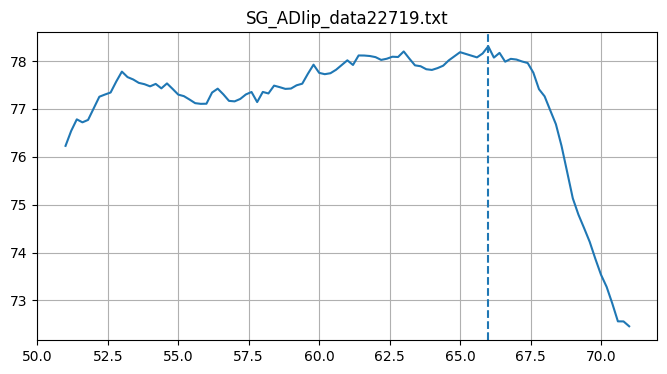

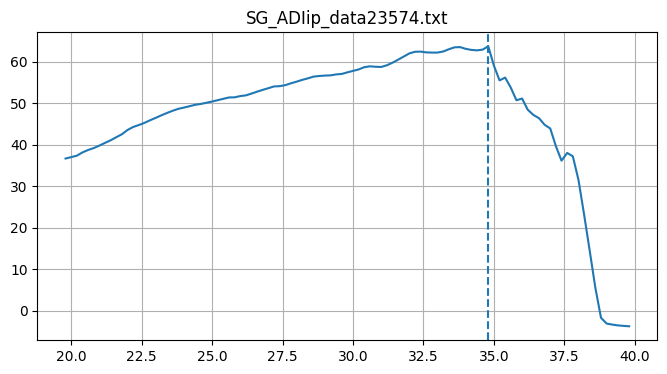

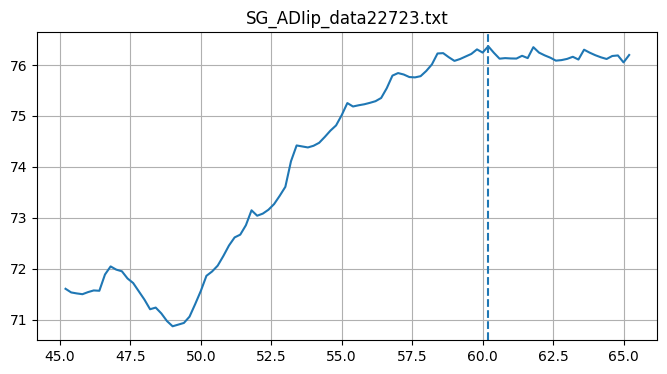

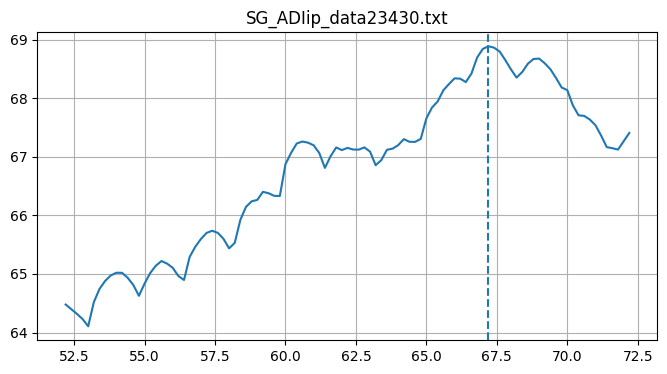

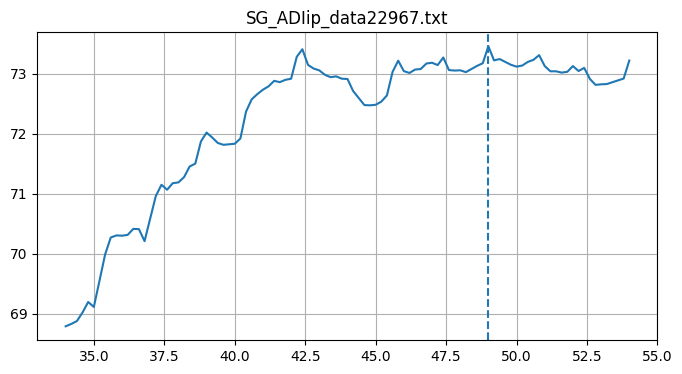

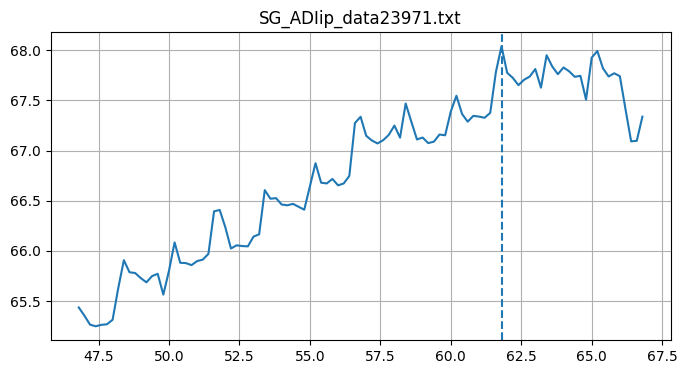

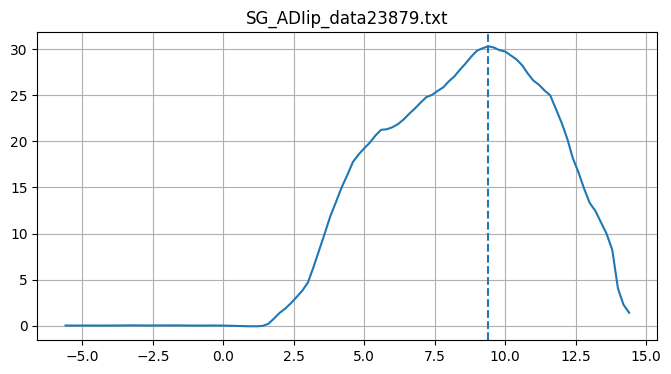

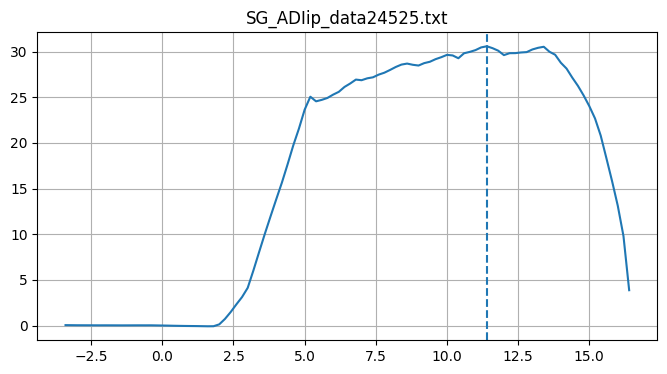

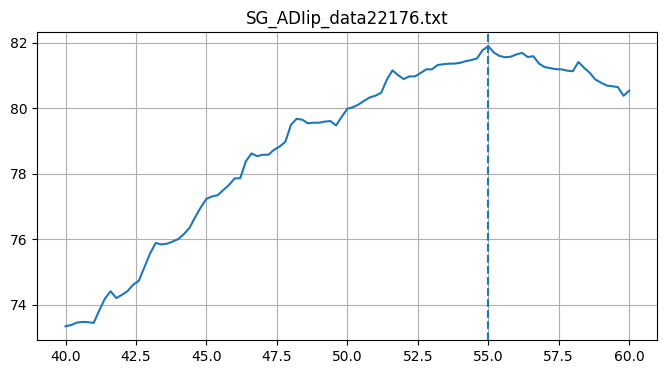

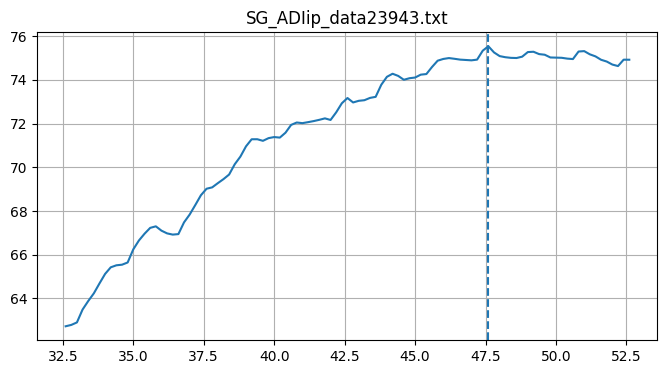

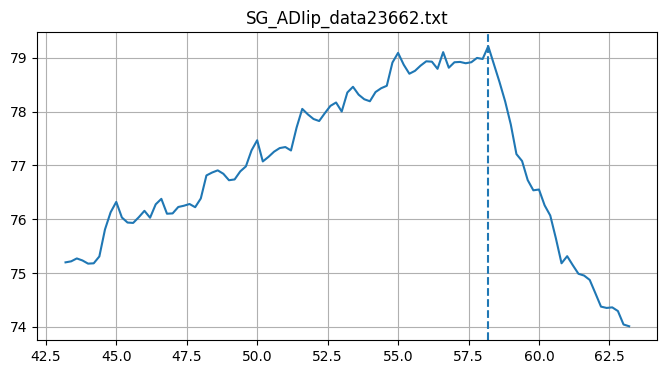

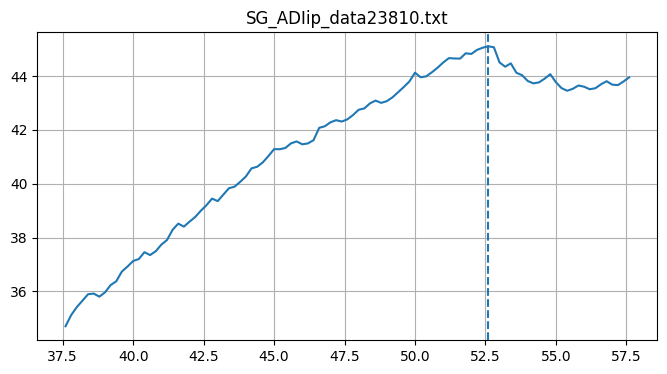

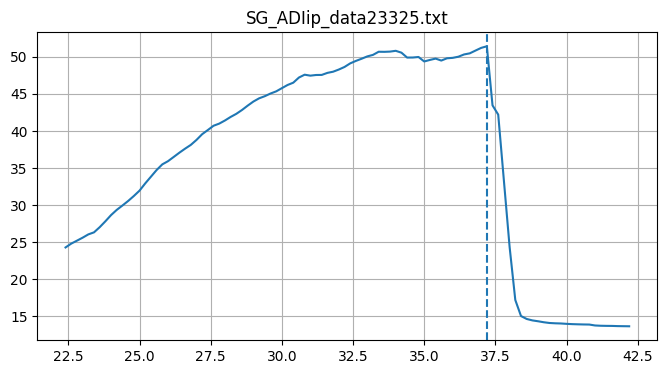

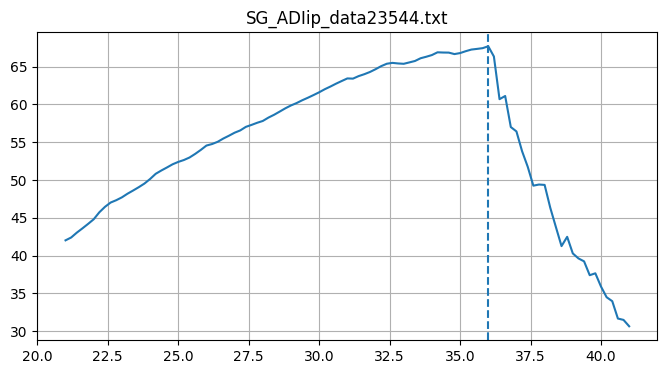

In [ ]:
for file in sample_files:

    df = pd.read_csv(
        file,
        sep=r"\s+",
        header=None,
        names=["Time", "Current"]
    )

    peak_idx = df["Current"].idxmax()

    peak_time = df.loc[peak_idx, "Time"]

    start_time = peak_time - 15
    end_time = peak_time + 5

    window_df = df[
        (df["Time"] >= start_time)
        &
        (df["Time"] <= end_time)
    ].copy()

    plt.figure(figsize=(8,4))

    plt.plot(
        window_df["Time"],
        window_df["Current"]
    )

    plt.axvline(
        peak_time,
        linestyle="--"
    )

    plt.title(
        os.path.basename(file)
    )

    plt.grid(True)

    plt.show()

In [ ]:
labels = []

In [ ]:
from scipy.optimize import curve_fit
from sklearn.metrics import r2_score

In [ ]:
import numpy as np
import pandas as pd
import os
import random
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
from scipy.optimize import curve_fit


# ---------- MODELS ----------

def linear_func(x, a, b):
    return a * x + b


def exponential_func(x, a, tau, c):
    return c + a * np.exp(-x / tau)


def gaussian_func(x, a, mu, sigma, c):
    return a * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2)) + c


# ---------- ADJUSTED R² FUNCTION ----------

def adjusted_r2(r2, n, p):
    if n <= p + 1:
        return np.nan
    return 1 - (1 - r2) * (n - 1) / (n - p - 1)

In [ ]:
# ---------- PROOF: ±15ms WINDOW TEST ----------

file = files[0]

df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

peak_idx = df["Current"].idxmax()
peak_time = df.loc[peak_idx, "Time"]

start_time = peak_time - 15
end_time = peak_time + 5

window_df = df[
    (df["Time"] >= start_time) &
    (df["Time"] <= end_time)
].copy()

x = window_df["Time"].values
y = window_df["Current"].values

print("±15ms Window Length:", len(window_df))
print("Peak Time:", peak_time)

±15ms Window Length: 101
Peak Time: 58.8


Linear R²: 0.3270373556977808
Exponential R²: 0.8476136783385864
Gaussian R²: 0.9467541932853323


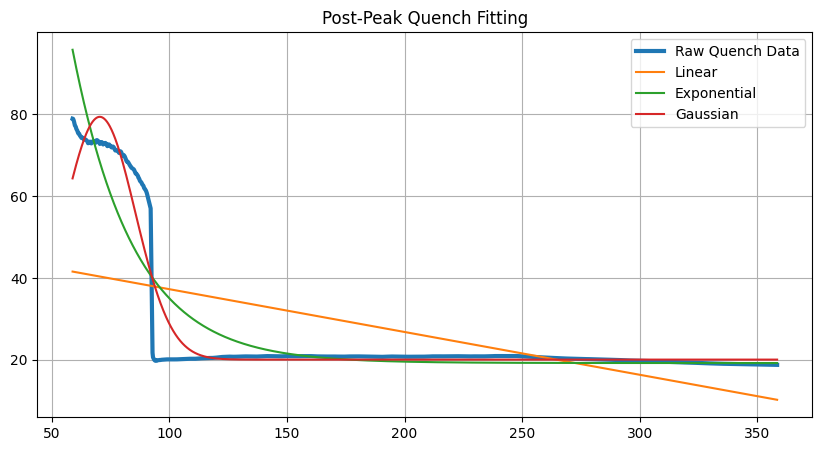

In [ ]:
# ---------- SINGLE FILE: POST-PEAK FIT ----------

file = files[0]

df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

peak_idx = df["Current"].idxmax()
peak_time = df.loc[peak_idx, "Time"]

# ✅ Post-peak only
quench_df = df[df["Time"] >= peak_time].copy()

x = quench_df["Time"].values
y = quench_df["Current"].values

x_shifted = x - x[0]

# --- Linear ---
lin_params, _ = curve_fit(linear_func, x, y)
lin_pred = linear_func(x, *lin_params)
lin_r2 = r2_score(y, lin_pred)

# --- Exponential ---
exp_params, _ = curve_fit(
    exponential_func,
    x_shifted,
    y,
    p0=[y[0]-y[-1], x_shifted.max()/3, y[-1]],
    bounds=([-np.inf, 1e-9, -np.inf], [np.inf, np.inf, np.inf]),
    maxfev=50000
)

exp_pred = exponential_func(x_shifted, *exp_params)
exp_r2 = r2_score(y, exp_pred)

# --- Gaussian ---
gauss_params, _ = curve_fit(
    gaussian_func,
    x,
    y,
    p0=[max(y), x[np.argmax(y)], 5, min(y)],
    maxfev=50000
)

gauss_pred = gaussian_func(x, *gauss_params)
gauss_r2 = r2_score(y, gauss_pred)

print("Linear R²:", lin_r2)
print("Exponential R²:", exp_r2)
print("Gaussian R²:", gauss_r2)

plt.figure(figsize=(10,5))
plt.plot(x, y, linewidth=3, label="Raw Quench Data")
plt.plot(x, lin_pred, label="Linear")
plt.plot(x, exp_pred, label="Exponential")
plt.plot(x, gauss_pred, label="Gaussian")
plt.legend()
plt.grid(True)
plt.title("Post-Peak Quench Fitting")
plt.show()

In [ ]:
# ---------- BATCH CLASSIFICATION (POST-PEAK + TRANSIENT REMOVED + ADJUSTED R²) ----------

test_files = random.sample(files, 20)

results = []

for file in test_files:

    df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

    peak_idx = df["Current"].idxmax()
    peak_time = df.loc[peak_idx, "Time"]

    quench_df = df[df["Time"] >= peak_time].copy()

    if len(quench_df) < 10:
        continue

    x = quench_df["Time"].values
    y = quench_df["Current"].values
    x_shifted = x - x[0]

    # ✅ Remove early transient (first 10%)
    cut = int(0.1 * len(x_shifted))

    x_shifted = x_shifted[cut:]
    x = x[cut:]
    y = y[cut:]

    if len(x) < 5:
        continue

    n = len(x)

    # --- Linear ---
    try:
        lin_params, _ = curve_fit(linear_func, x, y)
        lin_pred = linear_func(x, *lin_params)
        lin_r2 = r2_score(y, lin_pred)
        lin_adj = adjusted_r2(lin_r2, n, 2)
    except:
        lin_adj = np.nan

    # --- Exponential ---
    try:
        exp_params, _ = curve_fit(
            exponential_func,
            x_shifted,
            y,
            p0=[y[0] - y[-1], x_shifted.max()/3, y[-1]],
            bounds=([-np.inf, 1e-9, -np.inf], [np.inf, np.inf, np.inf]),
            maxfev=50000
        )
        exp_pred = exponential_func(x_shifted, *exp_params)
        exp_r2 = r2_score(y, exp_pred)
        exp_adj = adjusted_r2(exp_r2, n, 3)
    except:
        exp_adj = np.nan

    # --- Gaussian ---
    try:
        gauss_params, _ = curve_fit(
            gaussian_func,
            x,
            y,
            p0=[max(y), x[np.argmax(y)], 5, min(y)],
            maxfev=50000
        )
        gauss_pred = gaussian_func(x, *gauss_params)
        gauss_r2 = r2_score(y, gauss_pred)
        gauss_adj = adjusted_r2(gauss_r2, n, 4)
    except:
        gauss_adj = np.nan

    scores = {
        "Linear": lin_adj,
        "Exponential": exp_adj,
        "Gaussian": gauss_adj
    }

    valid_scores = {k: v for k, v in scores.items() if not np.isnan(v)}
    winner = max(valid_scores, key=valid_scores.get) if valid_scores else "None"

    results.append({
        "File": os.path.basename(file),
        "Linear_AdjR2": lin_adj,
        "Exponential_AdjR2": exp_adj,
        "Gaussian_AdjR2": gauss_adj,
        "Winner": winner
    })

results_df = pd.DataFrame(results)

print(results_df.to_string(index=False))

print("\n--- Winner Distribution (Adjusted R², Transient Removed) ---")
print(results_df["Winner"].value_counts())

print("\nMean Exponential Adj R²:", results_df["Exponential_AdjR2"].mean())
print("Mean Gaussian Adj R²:   ", results_df["Gaussian_AdjR2"].mean())

                  File  Linear_AdjR2  Exponential_AdjR2  Gaussian_AdjR2      Winner
SG_ADIip_data23372.txt      0.039156           0.882526        0.954514    Gaussian
SG_ADIip_data23836.txt      0.131136           0.897866        0.970449    Gaussian
SG_ADIip_data22967.txt      0.058063           0.347976        0.220085 Exponential
SG_ADIip_data24138.txt      0.138800           0.138056        0.902954    Gaussian
SG_ADIip_data21086.txt      0.169027           0.930829        0.976381    Gaussian
SG_ADIip_data21109.txt      0.011757           0.576254        0.544678 Exponential
SG_ADIip_data23310.txt      0.888062           0.887984        0.894386    Gaussian
SG_ADIip_data24188.txt      0.409744           0.409327        0.982023    Gaussian
SG_ADIip_data24556.txt      0.032207           0.031488        0.737270    Gaussian
SG_ADIip_data22652.txt      0.160271           0.859135        0.960434    Gaussian
SG_ADIip_data23655.txt      0.239432           0.238870        0.887808    G

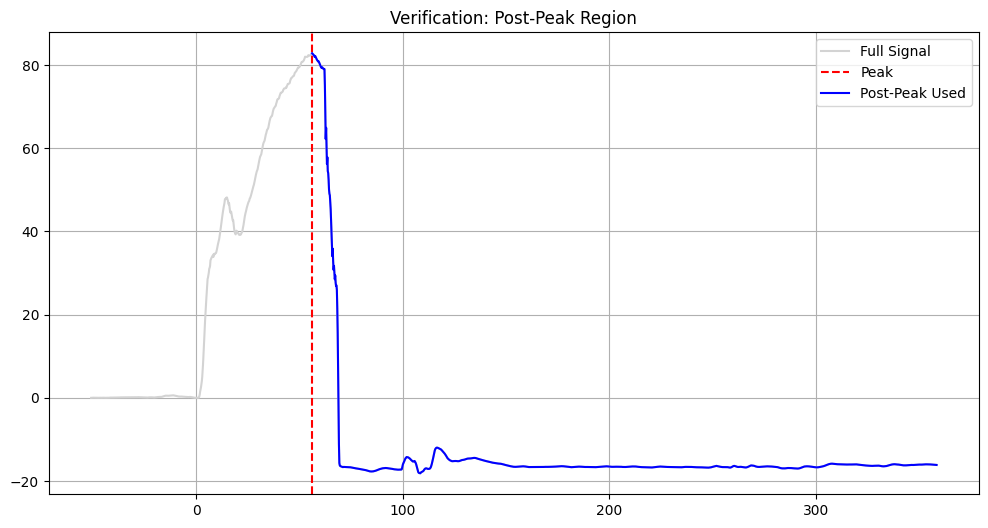

Peak time: 56.0
First quench time: 56.0
Equal? → True


In [ ]:
# ---------- VISUAL VERIFICATION ----------

file = test_files[0]

df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

peak_idx = df["Current"].idxmax()
peak_time = df.loc[peak_idx, "Time"]

quench_df = df[df["Time"] >= peak_time].copy()

plt.figure(figsize=(12,6))
plt.plot(df["Time"], df["Current"], color="lightgray", label="Full Signal")
plt.axvline(peak_time, color="red", linestyle="--", label="Peak")
plt.plot(quench_df["Time"], quench_df["Current"], color="blue", label="Post-Peak Used")
plt.legend()
plt.grid(True)
plt.title("Verification: Post-Peak Region")
plt.show()

print("Peak time:", peak_time)
print("First quench time:", quench_df["Time"].values[0])
print("Equal? →", peak_time == quench_df["Time"].values[0])

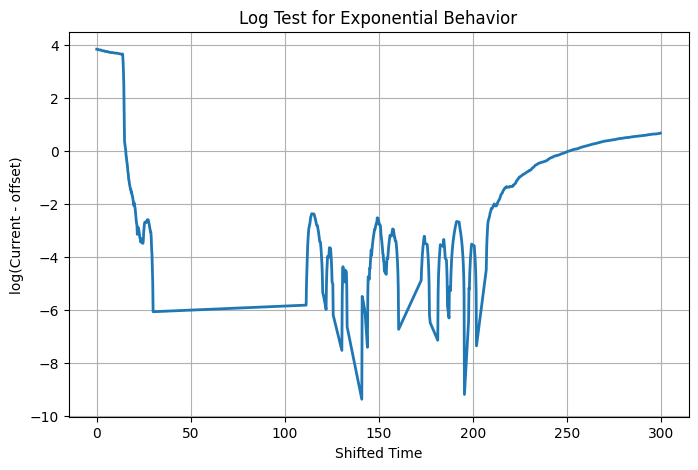

In [ ]:
plt.figure(figsize=(8,5))

# subtract offset from exponential fit
c = exp_params[2]
y_adjusted = y - c

mask = y_adjusted > 0

plt.plot(x_shifted[mask], np.log(y_adjusted[mask]), linewidth=2)

plt.xlabel("Shifted Time")
plt.ylabel("log(Current - offset)")
plt.title("Log Test for Exponential Behavior")
plt.grid(True)
plt.show()

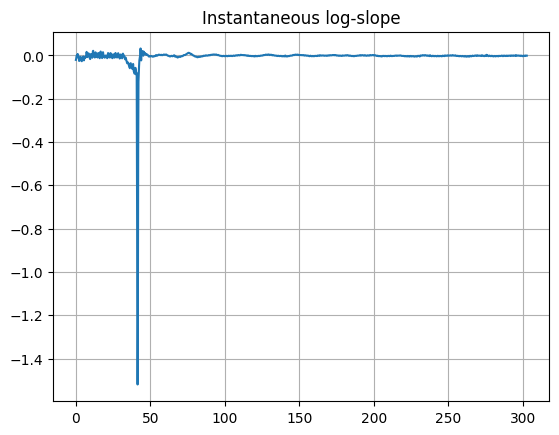

In [ ]:
slope = np.gradient(np.log(y), x_shifted)

plt.plot(x_shifted, slope)
plt.title("Instantaneous log-slope")
plt.grid(True)
plt.show()

## Generate labels for ALL 1521 files

In [ ]:
# ---------- GENERATE LABELS FOR ALL FILES ----------

from scipy.optimize import curve_fit
from sklearn.metrics import r2_score
import numpy as np
import pandas as pd
import os

all_results = []

failed_files = 0

for i, file in enumerate(files):

    if (i+1) % 100 == 0:
        print(f"Processing {i+1}/{len(files)}...")

    try:
        df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

        peak_idx = df["Current"].idxmax()
        peak_time = df.loc[peak_idx, "Time"]

        quench_df = df[df["Time"] >= peak_time].copy()

        if len(quench_df) < 10:
            failed_files += 1
            continue

        x = quench_df["Time"].values
        y = quench_df["Current"].values
        x_shifted = x - x[0]

        # Remove early transient (first 10%)
        cut = int(0.1 * len(x_shifted))
        x_shifted = x_shifted[cut:]
        x = x[cut:]
        y = y[cut:]

        if len(x) < 5:
            failed_files += 1
            continue

        n = len(x)

        # --- Linear ---
        try:
            lin_params, _ = curve_fit(linear_func, x, y)
            lin_pred = linear_func(x, *lin_params)
            lin_r2 = r2_score(y, lin_pred)
            lin_adj = adjusted_r2(lin_r2, n, 2)
        except:
            lin_adj = np.nan

        # --- Exponential ---
        try:
            exp_params, _ = curve_fit(
                exponential_func,
                x_shifted,
                y,
                p0=[y[0]-y[-1], x_shifted.max()/3, y[-1]],
                bounds=([-np.inf, 1e-9, -np.inf], [np.inf, np.inf, np.inf]),
                maxfev=50000
            )
            exp_pred = exponential_func(x_shifted, *exp_params)
            exp_r2 = r2_score(y, exp_pred)
            exp_adj = adjusted_r2(exp_r2, n, 3)
        except:
            exp_adj = np.nan

        # --- Gaussian ---
        try:
            gauss_params, _ = curve_fit(
                gaussian_func,
                x,
                y,
                p0=[max(y), x[np.argmax(y)], 5, min(y)],
                maxfev=50000
            )
            gauss_pred = gaussian_func(x, *gauss_params)
            gauss_r2 = r2_score(y, gauss_pred)
            gauss_adj = adjusted_r2(gauss_r2, n, 4)
        except:
            gauss_adj = np.nan

        scores = {
            "Linear": lin_adj,
            "Exponential": exp_adj,
            "Gaussian": gauss_adj
        }

        valid_scores = {k: v for k, v in scores.items() if not np.isnan(v)}
        winner = max(valid_scores, key=valid_scores.get) if valid_scores else "None"

        all_results.append({
            "File": os.path.basename(file),
            "FilePath": file,
            "Linear_AdjR2": lin_adj,
            "Exponential_AdjR2": exp_adj,
            "Gaussian_AdjR2": gauss_adj,
            "Label": winner
        })

    except Exception as e:
        failed_files += 1
        continue

all_results_df = pd.DataFrame(all_results)

print(f"\n{'='*60}")
print(f"Total files processed: {len(all_results_df)}")
print(f"Failed files: {failed_files}")
print(f"{'='*60}")

Processing 100/1521...
Processing 200/1521...
Processing 300/1521...
Processing 400/1521...
Processing 500/1521...
Processing 600/1521...
Processing 700/1521...
Processing 800/1521...
Processing 900/1521...
Processing 1000/1521...
Processing 1100/1521...
Processing 1200/1521...
Processing 1300/1521...
Processing 1400/1521...
Processing 1500/1521...

Total files processed: 1520
Failed files: 1


--- Label Distribution ---
Label
Gaussian       1311
Linear          117
Exponential      92
Name: count, dtype: int64

--- Percentage ---
Label
Gaussian       86.250000
Linear          7.697368
Exponential     6.052632
Name: proportion, dtype: float64


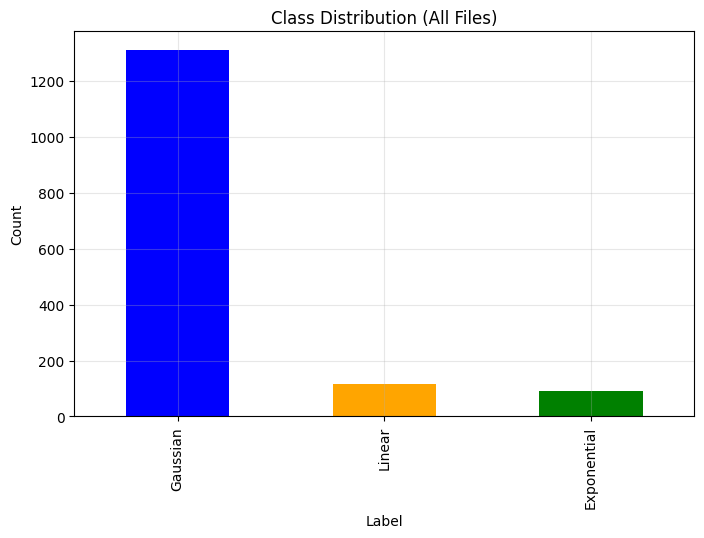

In [ ]:
# ---------- CLASS DISTRIBUTION ----------

print("--- Label Distribution ---")
print(all_results_df["Label"].value_counts())

print("\n--- Percentage ---")
print(all_results_df["Label"].value_counts(normalize=True) * 100)

# Plot distribution
plt.figure(figsize=(8, 5))
all_results_df["Label"].value_counts().plot(kind="bar", color=["blue", "orange", "green"])
plt.title("Class Distribution (All Files)")
plt.ylabel("Count")
plt.xlabel("Label")
plt.grid(True, alpha=0.3)
plt.show()

### Feature Extraction For ML

In [ ]:
# ---------- FEATURE EXTRACTION ----------

feature_list = []

for i, row in all_results_df.iterrows():

    if (i+1) % 100 == 0:
        print(f"Extracting features {i+1}/{len(all_results_df)}...")

    try:
        file = row["FilePath"]

        df = pd.read_csv(file, sep=r"\s+", header=None, names=["Time", "Current"])

        peak_idx = df["Current"].idxmax()
        peak_time = df.loc[peak_idx, "Time"]

        quench_df = df[df["Time"] >= peak_time].copy()

        x = quench_df["Time"].values
        y = quench_df["Current"].values
        x_shifted = x - x[0]

        # Remove early transient
        cut = int(0.1 * len(x_shifted))
        x_shifted = x_shifted[cut:]
        x = x[cut:]
        y = y[cut:]

        if len(x) < 5:
            continue

        # --- FEATURES ---

        # Basic current features
        initial_current = y[0]
        final_current = y[-1]
        current_range = y.max() - y.min()
        mean_current = np.mean(y)
        std_current = np.std(y)

        # Duration
        quench_duration = x_shifted[-1] - x_shifted[0]

        # Slope features
        dy = np.gradient(y, x_shifted)
        mean_slope = np.mean(dy)
        max_neg_slope = np.min(dy)
        std_slope = np.std(dy)

        # Log features
        y_positive = y[y > 0]
        if len(y_positive) > 2:
            log_y = np.log(y_positive)
            x_log = x_shifted[:len(y_positive)]
            log_slope = np.gradient(log_y, x_log)
            mean_log_slope = np.mean(log_slope)
            std_log_slope = np.std(log_slope)
        else:
            mean_log_slope = np.nan
            std_log_slope = np.nan

        # Curvature (second derivative)
        d2y = np.gradient(dy, x_shifted)
        mean_curvature = np.mean(d2y)
        std_curvature = np.std(d2y)

        # Decay ratio
        if initial_current != 0:
            decay_ratio = final_current / initial_current
        else:
            decay_ratio = np.nan

        # Number of data points
        n_points = len(x)

        # R² values from labeling
        lin_adj = row["Linear_AdjR2"]
        exp_adj = row["Exponential_AdjR2"]
        gauss_adj = row["Gaussian_AdjR2"]

        feature_list.append({
            "File": row["File"],
            "initial_current": initial_current,
            "final_current": final_current,
            "current_range": current_range,
            "mean_current": mean_current,
            "std_current": std_current,
            "quench_duration": quench_duration,
            "mean_slope": mean_slope,
            "max_neg_slope": max_neg_slope,
            "std_slope": std_slope,
            "mean_log_slope": mean_log_slope,
            "std_log_slope": std_log_slope,
            "mean_curvature": mean_curvature,
            "std_curvature": std_curvature,
            "decay_ratio": decay_ratio,
            "n_points": n_points,
            "Label": row["Label"]
        })

    except:
        continue

features_df = pd.DataFrame(feature_list)

print(f"Features extracted for {len(features_df)} files")
print(f"Feature columns: {len(features_df.columns) - 2}")
print(features_df.head())

Extracting features 100/1520...
Extracting features 200/1520...
Extracting features 300/1520...
Extracting features 400/1520...
Extracting features 500/1520...
Extracting features 600/1520...
Extracting features 700/1520...
Extracting features 800/1520...
Extracting features 900/1520...
Extracting features 1000/1520...
Extracting features 1100/1520...
Extracting features 1200/1520...
Extracting features 1300/1520...
Extracting features 1400/1520...
Extracting features 1500/1520...
Features extracted for 1520 files
Feature columns: 15
                     File  initial_current  final_current  current_range  \
0  SG_ADIip_data23757.txt        62.751352      18.783705      43.968735   
1  SG_ADIip_data23314.txt        -2.062535      -0.326106       1.890345   
2  SG_ADIip_data23961.txt         3.530981       3.365414       1.800105   
3  SG_ADIip_data23960.txt        -0.861939      -2.517538       3.961661   
4  SG_ADIip_data23588.txt        -1.850651      -3.839355       2.979658   

   

In [ ]:
# ---------- PREPARE ML DATA ----------

# Remove rows with NaN
features_clean = features_df.dropna()

print(f"Clean samples: {len(features_clean)} / {len(features_df)}")

# Remove "None" labels
features_clean = features_clean[features_clean["Label"] != "None"]

print(f"After removing None: {len(features_clean)}")

# Separate features and labels
feature_columns = [
    "initial_current",
    "final_current",
    "current_range",
    "mean_current",
    "std_current",
    "quench_duration",
    "mean_slope",
    "max_neg_slope",
    "std_slope",
    "mean_log_slope",
    "std_log_slope",
    "mean_curvature",
    "std_curvature",
    "decay_ratio",
    "n_points"
]

X = features_clean[feature_columns].values
y = features_clean["Label"].values

print(f"\nX shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"\nLabel distribution:")
print(pd.Series(y).value_counts())

Clean samples: 1255 / 1520
After removing None: 1255

X shape: (1255, 15)
y shape: (1255,)

Label distribution:
Gaussian       1086
Linear           96
Exponential      73
Name: count, dtype: int64


## Train/Test Split

In [ ]:
# ---------- TRAIN/TEST SPLIT ----------

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Encode labels
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Label mapping:")
for i, label in enumerate(le.classes_):
    print(f"  {i} → {label}")

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(f"\nTrain: {len(X_train)}")
print(f"Test:  {len(X_test)}")

print(f"\nTrain distribution:")
print(pd.Series(le.inverse_transform(y_train)).value_counts())

print(f"\nTest distribution:")
print(pd.Series(le.inverse_transform(y_test)).value_counts())

Label mapping:
  0 → Exponential
  1 → Gaussian
  2 → Linear

Train: 1004
Test:  251

Train distribution:
Gaussian       869
Linear          77
Exponential     58
Name: count, dtype: int64

Test distribution:
Gaussian       217
Linear          19
Exponential     15
Name: count, dtype: int64


Train All 3 Models

In [ ]:
# ---------- TRAIN MODELS ----------

from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    balanced_accuracy_score,
    f1_score
)

# Install XGBoost if needed
try:
    from xgboost import XGBClassifier
except:
    !pip install xgboost
    from xgboost import XGBClassifier


# --- Random Forest ---
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    random_state=42,
    class_weight="balanced"
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

# --- SVM ---
svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)

# --- XGBoost ---
xgb = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    eval_metric="mlogloss",
    use_label_encoder=False
)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)

print("✅ All 3 models trained successfully!")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [17:59:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


✅ All 3 models trained successfully!


 Evaluate All 3 Models

In [ ]:
# ---------- EVALUATION ----------

models = {
    "Random Forest": rf_pred,
    "SVM": svm_pred,
    "XGBoost": xgb_pred
}

for name, pred in models.items():

    print(f"\n{'='*60}")
    print(f"MODEL: {name}")
    print(f"{'='*60}")

    print("\nClassification Report:")
    print(classification_report(
        y_test,
        pred,
        target_names=le.classes_
    ))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, pred))

    bal_acc = balanced_accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")

    print(f"\nBalanced Accuracy: {bal_acc:.4f}")
    print(f"Weighted F1 Score: {f1:.4f}")


MODEL: Random Forest

Classification Report:
              precision    recall  f1-score   support

 Exponential       0.29      0.27      0.28        15
    Gaussian       0.91      0.94      0.92       217
      Linear       0.67      0.42      0.52        19

    accuracy                           0.86       251
   macro avg       0.62      0.54      0.57       251
weighted avg       0.85      0.86      0.85       251

Confusion Matrix:
[[  4  11   0]
 [  9 204   4]
 [  1  10   8]]

Balanced Accuracy: 0.5426
Weighted F1 Score: 0.8536

MODEL: SVM

Classification Report:
              precision    recall  f1-score   support

 Exponential       0.18      0.47      0.26        15
    Gaussian       0.96      0.82      0.89       217
      Linear       0.37      0.53      0.43        19

    accuracy                           0.78       251
   macro avg       0.50      0.60      0.53       251
weighted avg       0.87      0.78      0.81       251

Confusion Matrix:
[[  7   2   6]
 [ 28 

## Compare Models Side by Side

        Model  Balanced_Accuracy  F1_Score
Random Forest           0.542604  0.853594
          SVM           0.604420  0.814020
      XGBoost           0.608241  0.858077


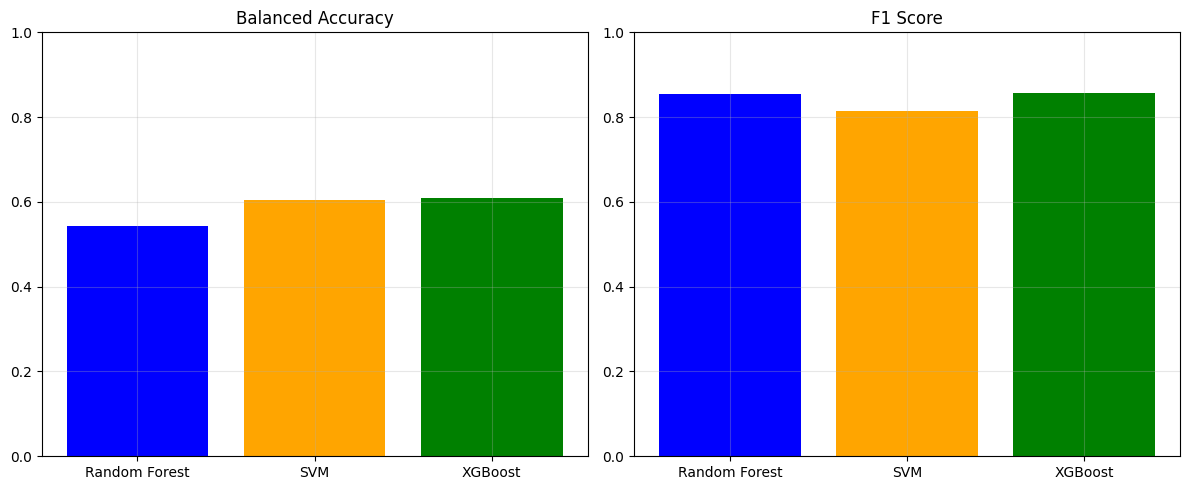

In [ ]:
# ---------- MODEL COMPARISON ----------

comparison = []

for name, pred in models.items():
    bal_acc = balanced_accuracy_score(y_test, pred)
    f1 = f1_score(y_test, pred, average="weighted")

    comparison.append({
        "Model": name,
        "Balanced_Accuracy": bal_acc,
        "F1_Score": f1
    })

comparison_df = pd.DataFrame(comparison)

print(comparison_df.to_string(index=False))

# Plot comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(comparison_df["Model"], comparison_df["Balanced_Accuracy"], color=["blue", "orange", "green"])
axes[0].set_title("Balanced Accuracy")
axes[0].set_ylim(0, 1)
axes[0].grid(True, alpha=0.3)

axes[1].bar(comparison_df["Model"], comparison_df["F1_Score"], color=["blue", "orange", "green"])
axes[1].set_title("F1 Score")
axes[1].set_ylim(0, 1)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Feature Importance (Random Forest)

        Feature  Importance
     mean_slope    0.132454
  std_curvature    0.109774
 mean_log_slope    0.106931
  current_range    0.085204
  max_neg_slope    0.083414
      std_slope    0.079819
    std_current    0.073162
    decay_ratio    0.071810
  std_log_slope    0.054840
 mean_curvature    0.047552
initial_current    0.041979
  final_current    0.041584
   mean_current    0.030629
       n_points    0.020441
quench_duration    0.020407


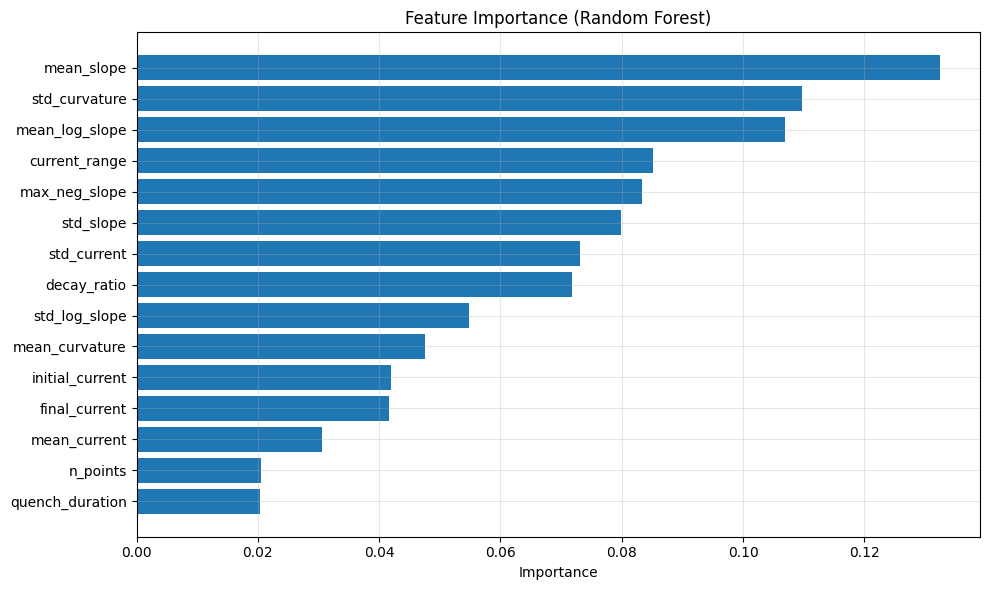

In [ ]:
# ---------- FEATURE IMPORTANCE ----------

importances = rf.feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": importances
}).sort_values("Importance", ascending=False)

print(importance_df.to_string(index=False))

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"], importance_df["Importance"])
plt.xlabel("Importance")
plt.title("Feature Importance (Random Forest)")
plt.gca().invert_yaxis()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Confusion Matrix Visualization

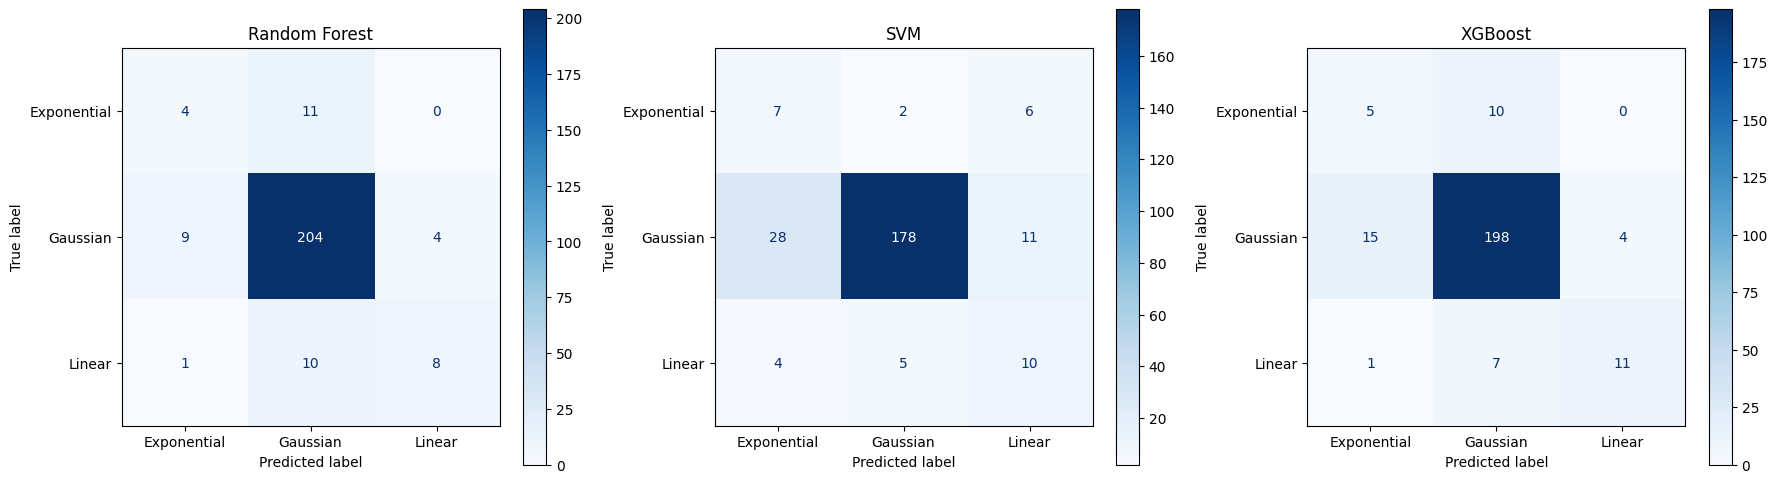

In [ ]:
# ---------- CONFUSION MATRIX PLOTS ----------

from sklearn.metrics import ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pred) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_predictions(
        le.inverse_transform(y_test),
        le.inverse_transform(pred),
        ax=ax,
        cmap="Blues"
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

In [ ]:
print(classification_report(y_test, xgb_pred, target_names=le.classes_))

              precision    recall  f1-score   support

 Exponential       0.24      0.33      0.28        15
    Gaussian       0.92      0.91      0.92       217
      Linear       0.73      0.58      0.65        19

    accuracy                           0.85       251
   macro avg       0.63      0.61      0.61       251
weighted avg       0.87      0.85      0.86       251



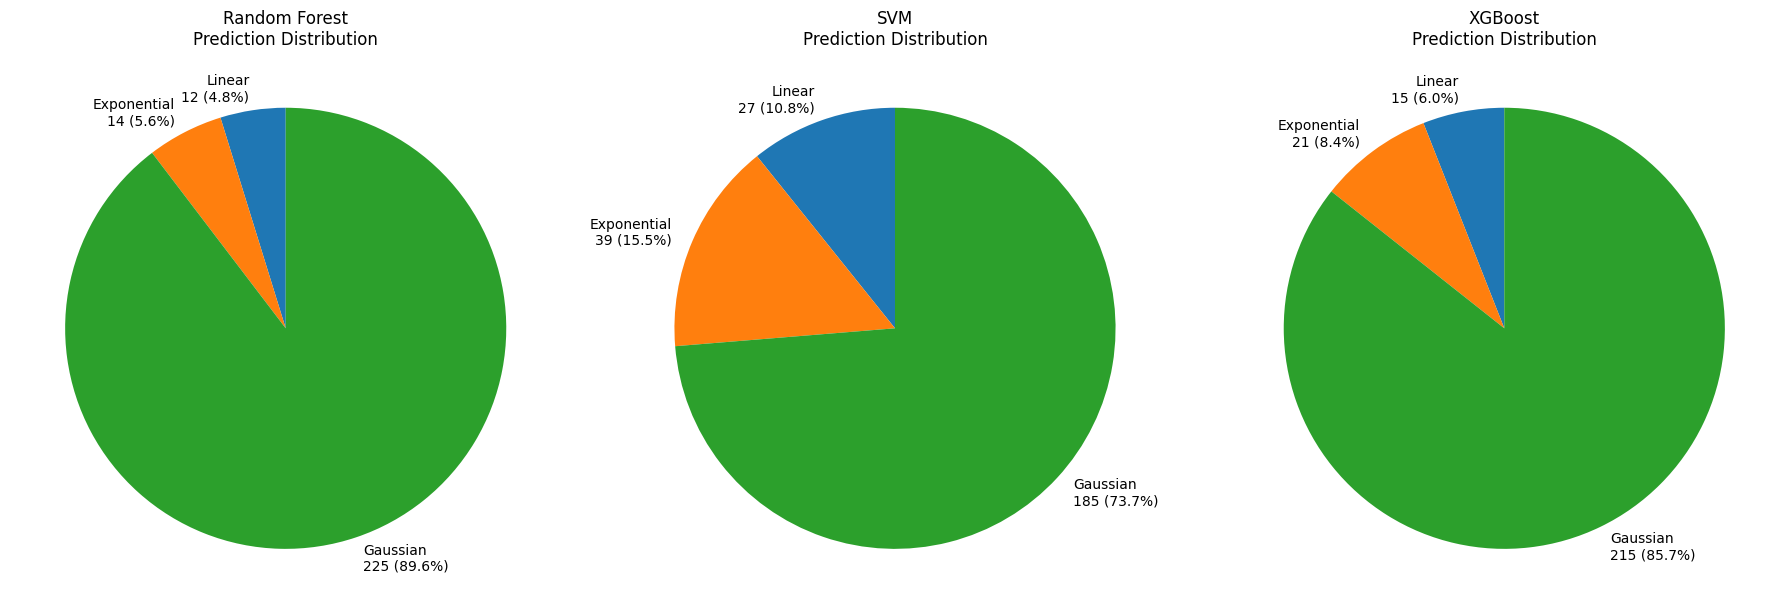

In [ ]:
# ---------- PIE CHARTS: CLASS DISTRIBUTION PER MODEL ----------

import matplotlib.pyplot as plt
import pandas as pd

# Convert encoded predictions back to original class names
rf_labels  = le.inverse_transform(rf_pred)
svm_labels = le.inverse_transform(svm_pred)
xgb_labels = le.inverse_transform(xgb_pred)

models_predictions = {
    "Random Forest": rf_labels,
    "SVM": svm_labels,
    "XGBoost": xgb_labels
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (model_name, labels) in zip(axes, models_predictions.items()):

    counts = pd.Series(labels).value_counts()

    # Ensure consistent order
    counts = counts.reindex(["Linear", "Exponential", "Gaussian"], fill_value=0)

    total = counts.sum()

    labels_with_counts = [
        f"{cls}\n{counts[cls]} ({counts[cls]/total*100:.1f}%)"
        for cls in counts.index
    ]

    ax.pie(
        counts,
        labels=labels_with_counts,
        autopct=None,
        startangle=90
    )

    ax.set_title(f"{model_name}\nPrediction Distribution")

plt.tight_layout()
plt.show()

           Model  Balanced Accuracy  Weighted F1 Score
0  Random Forest           0.542604           0.853594
1            SVM           0.604420           0.814020
2        XGBoost           0.608241           0.858077


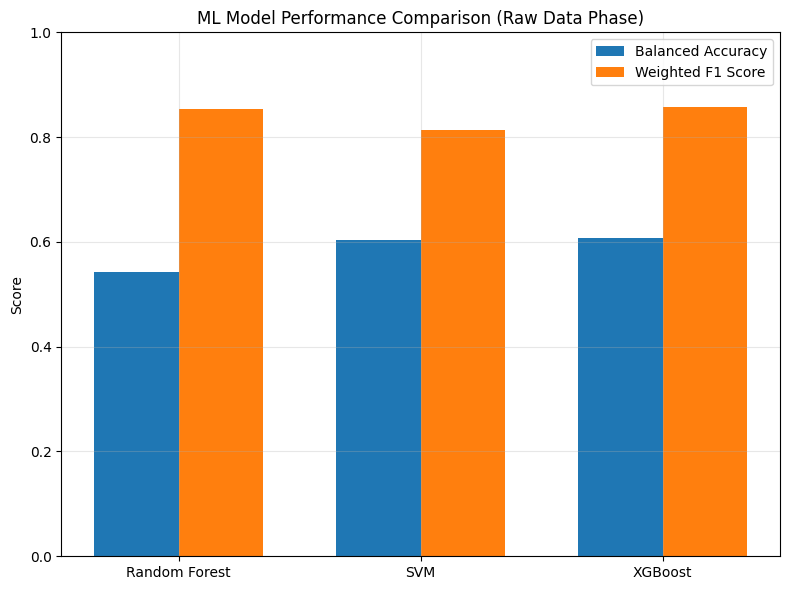

In [ ]:
# ---------- MODEL PERFORMANCE COMPARISON GRAPH ----------

import matplotlib.pyplot as plt
import pandas as pd

# Create comparison DataFrame
comparison_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "XGBoost"],
    "Balanced Accuracy": [
        balanced_accuracy_score(y_test, rf_pred),
        balanced_accuracy_score(y_test, svm_pred),
        balanced_accuracy_score(y_test, xgb_pred)
    ],
    "Weighted F1 Score": [
        f1_score(y_test, rf_pred, average="weighted"),
        f1_score(y_test, svm_pred, average="weighted"),
        f1_score(y_test, xgb_pred, average="weighted")
    ]
})

print(comparison_df)

# Plot
fig, ax = plt.subplots(figsize=(8, 6))

bar_width = 0.35
x = range(len(comparison_df))

ax.bar(
    [i - bar_width/2 for i in x],
    comparison_df["Balanced Accuracy"],
    width=bar_width,
    label="Balanced Accuracy"
)

ax.bar(
    [i + bar_width/2 for i in x],
    comparison_df["Weighted F1 Score"],
    width=bar_width,
    label="Weighted F1 Score"
)

ax.set_xticks(x)
ax.set_xticklabels(comparison_df["Model"])
ax.set_ylim(0, 1)
ax.set_ylabel("Score")
ax.set_title("ML Model Performance Comparison (Raw Data Phase)")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

           Model  Combined Score
0  Random Forest        0.698099
1            SVM        0.709220
2        XGBoost        0.733159


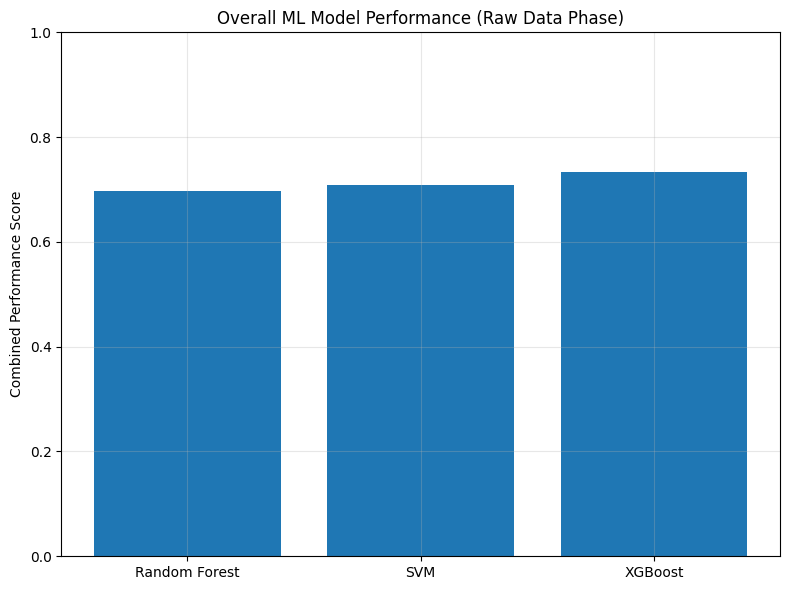

In [ ]:
# ---------- COMBINED PERFORMANCE SCORE (SINGLE BAR PER MODEL) ----------

import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import balanced_accuracy_score, f1_score

# Calculate scores
rf_bal = balanced_accuracy_score(y_test, rf_pred)
rf_f1  = f1_score(y_test, rf_pred, average="weighted")

svm_bal = balanced_accuracy_score(y_test, svm_pred)
svm_f1  = f1_score(y_test, svm_pred, average="weighted")

xgb_bal = balanced_accuracy_score(y_test, xgb_pred)
xgb_f1  = f1_score(y_test, xgb_pred, average="weighted")

# Combined score (average of the two)
rf_score  = (rf_bal + rf_f1) / 2
svm_score = (svm_bal + svm_f1) / 2
xgb_score = (xgb_bal + xgb_f1) / 2

# Create dataframe
combined_df = pd.DataFrame({
    "Model": ["Random Forest", "SVM", "XGBoost"],
    "Combined Score": [rf_score, svm_score, xgb_score]
})

print(combined_df)

# Plot single-bar comparison
plt.figure(figsize=(8,6))
plt.bar(combined_df["Model"], combined_df["Combined Score"])
plt.ylim(0, 1)
plt.ylabel("Combined Performance Score")
plt.title("Overall ML Model Performance (Raw Data Phase)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

So According to our graph we can say the best ML model acc to combined score of balanced score and weighted f1 score accuracy matrices is
# Accuracy
# XGBoost>SVM>Random Forest

#Phase 1- Raw Data Key Findings

* XGBoost performed best overall, followed by SVM and then Random Forest based on combined performance metrics.

* The raw dataset is highly imbalanced, with Gaussian dominating (~86%), followed by Linear and then Exponential.

* Raw quench signals show multi-phase and diverse decay behavior, not strictly single-exponential.

* Exponential quenches are difficult to detect in raw data due to noise and structural overlap with Gaussian patterns.

* Phase 1 establishes a clear baseline showing that lack of preprocessing reduces class separability and model performance.


